In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
print("=" * 80)
print("PHASE A.1: LOAD DATA & SANITY CHECKS")
print("=" * 80)

# Load data
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")

print("\n--- First 5 rows of train ---")
print(train.head())

print("\n--- Random 5 rows of train ---")
print(train.sample(5, random_state=42))

# Uniqueness checks
print(f"\nUnique sample_ids in train: {train['sample_id'].nunique()} / {len(train)}")
print(f"Unique sample_ids in test: {test['sample_id'].nunique()} / {len(test)}")
print(f"Are all train sample_ids unique? {train['sample_id'].nunique() == len(train)}")
print(f"Are all test sample_ids unique? {test['sample_id'].nunique() == len(test)}")

# Missing value counts
print("\n--- Missing Values in Train ---")
print(train.isnull().sum())

print("\n--- Missing Values in Test ---")
print(test.isnull().sum())

# Save basic stats
os.makedirs('../outputs/logs', exist_ok=True)
basic_stats = pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [len(train), len(test)],
    'missing_catalog': [train['catalog_content'].isnull().sum(), test['catalog_content'].isnull().sum()],
    'missing_image': [train['image_link'].isnull().sum(), test['image_link'].isnull().sum()]
})
basic_stats.to_csv('../outputs/logs/eda_basic.csv', index=False)
print("\n✓ Saved: outputs/logs/eda_basic.csv")

PHASE A.1: LOAD DATA & SANITY CHECKS

Train shape: (75000, 4)
Test shape: (75000, 3)

--- First 5 rows of train ---
   sample_id                                    catalog_content  \
0      33127  Item Name: La Victoria Green Taco Sauce Mild, ...   
1     198967  Item Name: Salerno Cookies, The Original Butte...   
2     261251  Item Name: Bear Creek Hearty Soup Bowl, Creamy...   
3      55858  Item Name: Judee’s Blue Cheese Powder 11.25 oz...   
4     292686  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...   

                                          image_link  price  
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89  
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12  
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97  
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34  
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49  

--- Random 5 rows of train ---
       sample_id                                    catalog_content  \
26837 


PHASE A.2: PRICE DISTRIBUTION & STATISTICS

--- Price Summary Statistics ---
count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64

--- Price Percentiles ---
  0.1%: ₹0.66
  1.0%: ₹1.32
  5.0%: ₹2.44
 25.0%: ₹6.79
 50.0%: ₹14.00
 75.0%: ₹28.62
 95.0%: ₹75.71
 99.0%: ₹145.25
 99.9%: ₹322.12

Zero prices: 0
Negative prices: 0

Extreme outliers (>99.9%): 75
Max price: ₹2,796.00

✓ Saved: outputs/plots/price_hist.png


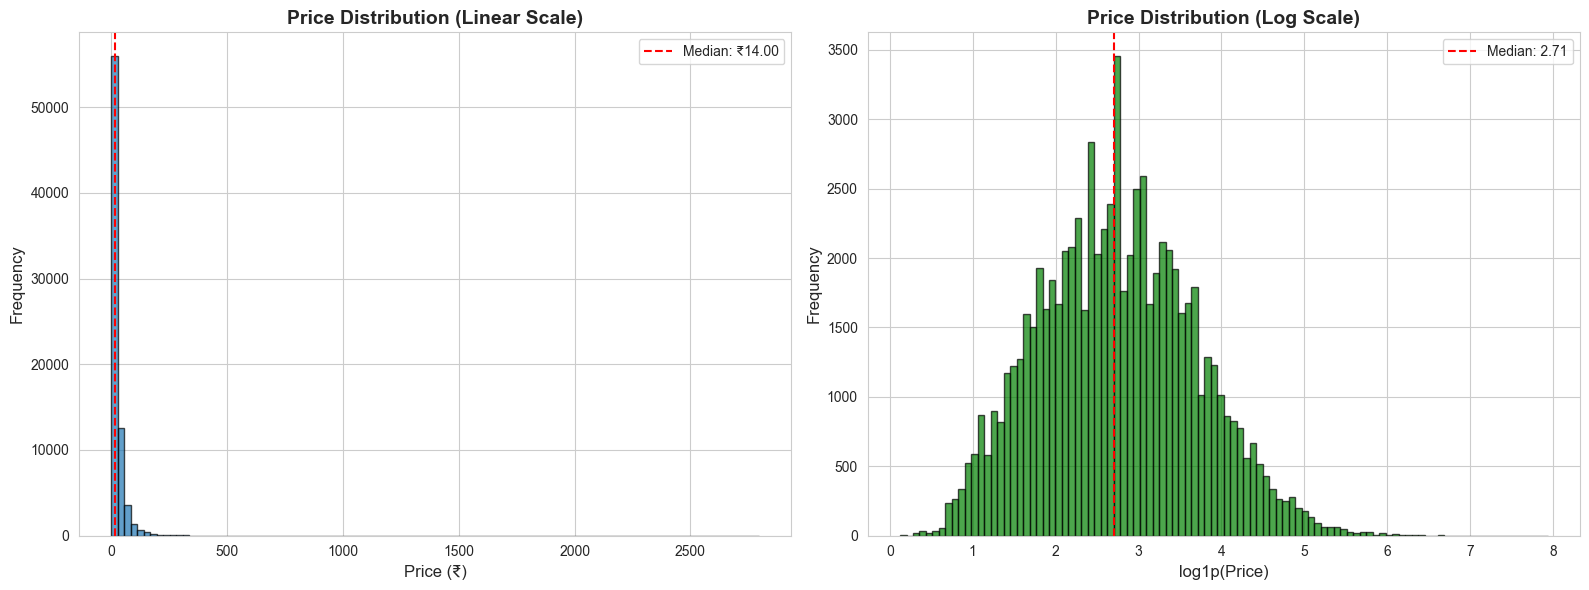

✓ Saved: outputs/plots/price_boxplot.png


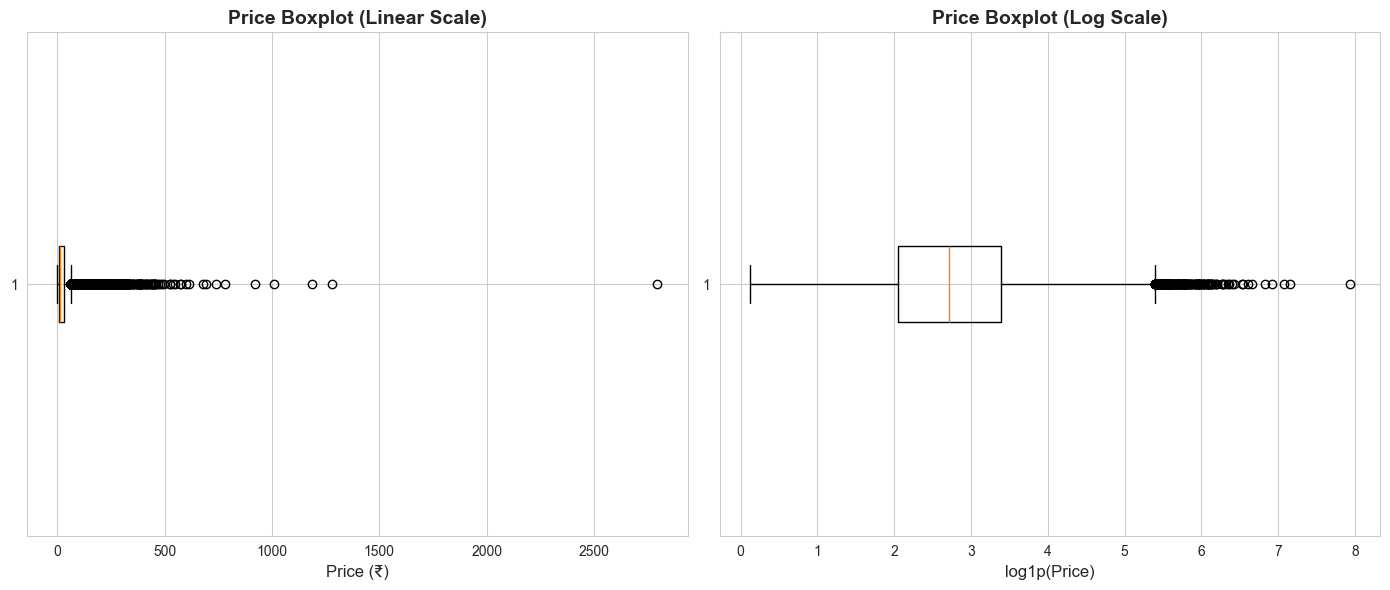


📊 DECISION: Distribution is heavily right-skewed. Use y = log1p(price) for modeling.


In [3]:
print("\n" + "=" * 80)
print("PHASE A.2: PRICE DISTRIBUTION & STATISTICS")
print("=" * 80)

# Summary statistics
print("\n--- Price Summary Statistics ---")
print(train['price'].describe())

# Percentiles
percentiles = [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]
price_percentiles = np.percentile(train['price'], percentiles)
print("\n--- Price Percentiles ---")
for p, val in zip(percentiles, price_percentiles):
    print(f"{p:5.1f}%: ₹{val:,.2f}")

# Check for invalid prices
print(f"\nZero prices: {(train['price'] == 0).sum()}")
print(f"Negative prices: {(train['price'] < 0).sum()}")

# Identify extreme outliers
p999 = np.percentile(train['price'], 99.9)
extreme_outliers = train[train['price'] > p999]
print(f"\nExtreme outliers (>99.9%): {len(extreme_outliers)}")
print(f"Max price: ₹{train['price'].max():,.2f}")

# Plot price distribution
os.makedirs('../outputs/plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale histogram
axes[0].hist(train['price'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Price (₹)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Price Distribution (Linear Scale)', fontsize=14, fontweight='bold')
axes[0].axvline(train['price'].median(), color='red', linestyle='--', label=f'Median: ₹{train["price"].median():.2f}')
axes[0].legend()

# Log scale histogram
axes[1].hist(np.log1p(train['price']), bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('log1p(Price)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].axvline(np.log1p(train['price'].median()), color='red', linestyle='--', label=f'Median: {np.log1p(train["price"].median()):.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/plots/price_hist.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: outputs/plots/price_hist.png")
plt.show()

# Boxplot for outliers
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.boxplot(train['price'], vert=False)
plt.xlabel('Price (₹)', fontsize=12)
plt.title('Price Boxplot (Linear Scale)', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
plt.boxplot(np.log1p(train['price']), vert=False)
plt.xlabel('log1p(Price)', fontsize=12)
plt.title('Price Boxplot (Log Scale)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/price_boxplot.png', dpi=300, bbox_inches='tight')
print("✓ Saved: outputs/plots/price_boxplot.png")
plt.show()

print("\n📊 DECISION: Distribution is heavily right-skewed. Use y = log1p(price) for modeling.")


PHASE A.3: CATALOG CONTENT ANALYSIS
✓ Saved: outputs/samples/catalog_samples.txt

--- Catalog Content Length Statistics ---
       content_len_chars  content_len_words
count       75000.000000       75000.000000
mean          908.886547         147.851693
std           852.896151         137.068731
min            32.000000           7.000000
25%           251.000000          42.000000
50%           643.000000         104.000000
75%          1280.000000         208.000000
max          7894.000000        1333.000000

✓ Saved: outputs/plots/content_length_dist.png


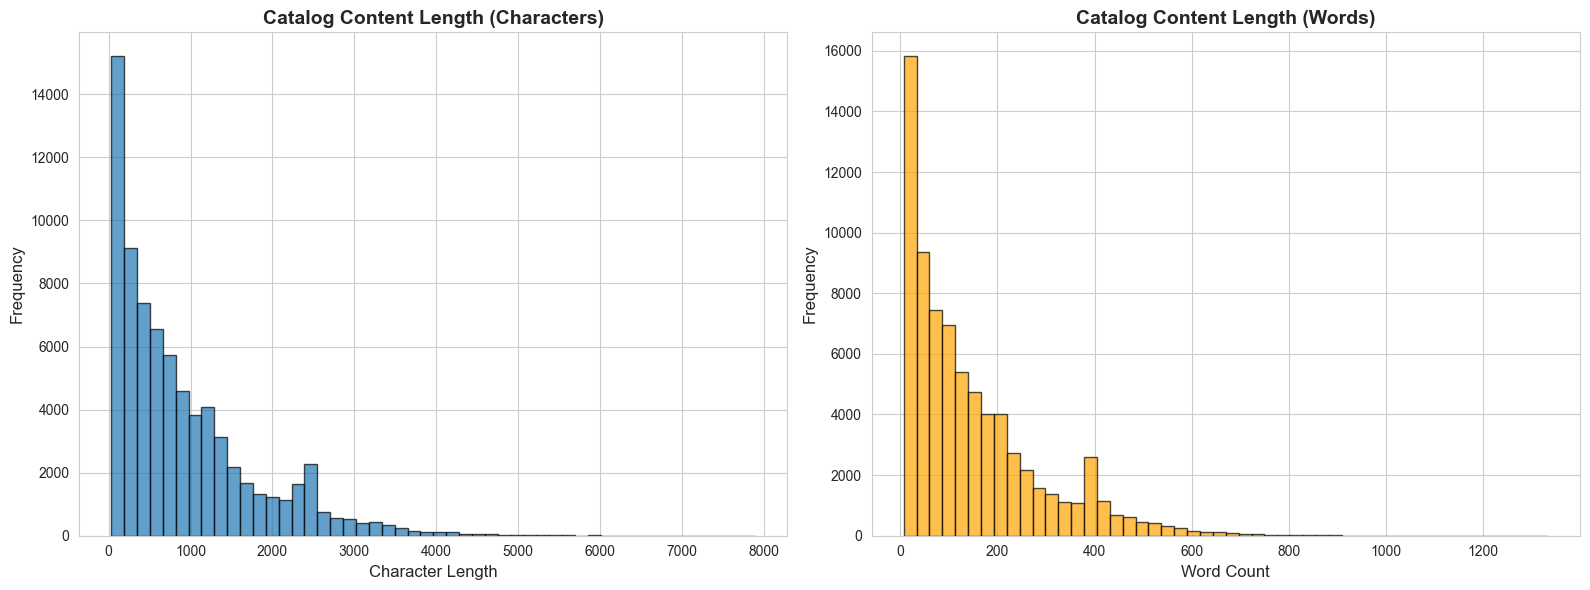


--- Extracting Top Tokens ---
✓ Saved: outputs/analysis/top_tokens.csv
✓ Saved: outputs/analysis/top_bigrams.csv
pack_of: 20733 occurrences (27.6%)
pack: 31773 occurrences (42.4%)
pcs: 291 occurrences (0.4%)
piece: 3160 occurrences (4.2%)
count: 20864 occurrences (27.8%)
item_pack_quantity: 0 occurrences (0.0%)
x_pattern: 1231 occurrences (1.6%)

✓ Saved: outputs/analysis/catalog_patterns.csv

📊 DECISION: IPQ patterns are frequent. Build robust IPQ extractor.

PHASE A.4: TEXT-PRICE CORRELATION ANALYSIS

--- Correlations with Price ---
content_len_chars vs price: 0.1468
content_len_words vs price: 0.1444

--- Price Bin Summary ---
           price                       content_len_chars content_len_words  \
             min      max   mean count              mean              mean   
price_bin                                                                    
0           0.13     3.57   2.36  7501            503.90             84.20   
1           3.57     5.60   4.59  7504           

In [4]:
print("\n" + "=" * 80)
print("PHASE A.3: CATALOG CONTENT ANALYSIS")
print("=" * 80)

# Sample catalog content
os.makedirs('../outputs/samples', exist_ok=True)
sample_catalog = train['catalog_content'].dropna().sample(50, random_state=42)
with open('../outputs/samples/catalog_samples.txt', 'w', encoding='utf-8') as f:
    for idx, content in enumerate(sample_catalog, 1):
        f.write(f"\n{'='*80}\nSAMPLE {idx}\n{'='*80}\n")
        f.write(content[:500])  # First 500 chars
        f.write("\n...\n" if len(content) > 500 else "\n")

print("✓ Saved: outputs/samples/catalog_samples.txt")

# Compute lengths
train['content_len_chars'] = train['catalog_content'].fillna('').str.len()
train['content_len_words'] = train['catalog_content'].fillna('').str.split().apply(len)

print("\n--- Catalog Content Length Statistics ---")
print(train[['content_len_chars', 'content_len_words']].describe())

# Plot length distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(train['content_len_chars'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Length', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Catalog Content Length (Characters)', fontsize=14, fontweight='bold')

axes[1].hist(train['content_len_words'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Catalog Content Length (Words)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/content_length_dist.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: outputs/plots/content_length_dist.png")
plt.show()

# Common tokens analysis
from sklearn.feature_extraction.text import CountVectorizer

print("\n--- Extracting Top Tokens ---")
vectorizer = CountVectorizer(max_features=200, lowercase=True, stop_words='english')
vectorizer.fit(train['catalog_content'].fillna(''))
top_tokens = vectorizer.get_feature_names_out()

# Bigrams
vectorizer_bigram = CountVectorizer(ngram_range=(2,2), max_features=200, lowercase=True, stop_words='english')
vectorizer_bigram.fit(train['catalog_content'].fillna(''))
top_bigrams = vectorizer_bigram.get_feature_names_out()

os.makedirs('../outputs/analysis', exist_ok=True)
pd.DataFrame({'top_tokens': top_tokens}).to_csv('../outputs/analysis/top_tokens.csv', index=False)
pd.DataFrame({'top_bigrams': top_bigrams}).to_csv('../outputs/analysis/top_bigrams.csv', index=False)
print("✓ Saved: outputs/analysis/top_tokens.csv")
print("✓ Saved: outputs/analysis/top_bigrams.csv")

# IPQ pattern search
ipq_patterns = {
    'pack_of': r'pack of',
    'pack': r'\bpack\b',
    'pcs': r'\bpcs\b',
    'piece': r'\bpiece',
    'count': r'\bcount\b',
    'item_pack_quantity': r'item pack quantity',
    'x_pattern': r'\d+\s*x\s*\d+'
}

pattern_counts = {}
for name, pattern in ipq_patterns.items():
    count = train['catalog_content'].fillna('').str.contains(pattern, case=False, regex=True).sum()
    pattern_counts[name] = count
    print(f"{name}: {count} occurrences ({count/len(train)*100:.1f}%)")

pd.DataFrame(list(pattern_counts.items()), columns=['pattern', 'count']).to_csv(
    '../outputs/analysis/catalog_patterns.csv', index=False
)
print("\n✓ Saved: outputs/analysis/catalog_patterns.csv")

print("\n📊 DECISION: IPQ patterns are frequent. Build robust IPQ extractor.")

# ==================== A.4 Text-Price Signals ====================
print("\n" + "=" * 80)
print("PHASE A.4: TEXT-PRICE CORRELATION ANALYSIS")
print("=" * 80)

# Simple correlations
correlations = {
    'content_len_chars vs price': train[['content_len_chars', 'price']].corr().iloc[0, 1],
    'content_len_words vs price': train[['content_len_words', 'price']].corr().iloc[0, 1],
}

print("\n--- Correlations with Price ---")
for key, val in correlations.items():
    print(f"{key}: {val:.4f}")

# Price bins analysis
train['price_bin'] = pd.qcut(train['price'], 10, labels=False, duplicates='drop')
price_bin_summary = train.groupby('price_bin').agg({
    'price': ['min', 'max', 'mean', 'count'],
    'content_len_chars': 'mean',
    'content_len_words': 'mean',
    'image_link': lambda x: x.notna().sum()
}).round(2)

print("\n--- Price Bin Summary ---")
print(price_bin_summary)

price_bin_summary.to_csv('../outputs/analysis/price_bin_summary.csv')
print("\n✓ Saved: outputs/analysis/price_bin_summary.csv")

In [5]:
print("\n" + "=" * 80)
print("PHASE A.5: IMAGE SAMPLE & QUALITY CHECK")
print("=" * 80)

# Sample images for download
sample_size = 100
sample_images = train.sample(sample_size, random_state=42)

print(f"\nSampling {sample_size} images for quality check...")
print("Note: Use the provided download_images function from src/utils.py")
print("Command: from src.utils import download_images")

# Create sample mapping
os.makedirs('../data/raw/sample_images', exist_ok=True)
sample_map = sample_images[['sample_id', 'image_link', 'price']].copy()
sample_map['local_path'] = sample_map['sample_id'].apply(
    lambda x: f'../data/raw/sample_images/{x}.jpg'
)
sample_map.to_csv('../data/raw/sample_images/map.csv', index=False)
print("✓ Saved: data/raw/sample_images/map.csv")

print("\n⚠️  ACTION REQUIRED: Run image download separately")
print("    See Phase C for full image download implementation")


PHASE A.5: IMAGE SAMPLE & QUALITY CHECK

Sampling 100 images for quality check...
Note: Use the provided download_images function from src/utils.py
Command: from src.utils import download_images
✓ Saved: data/raw/sample_images/map.csv

⚠️  ACTION REQUIRED: Run image download separately
    See Phase C for full image download implementation


In [8]:
print("\n" + "=" * 80)
print("PHASE A.6: CREATING EDA SUMMARY")
print("=" * 80)

eda_summary = """# EDA Summary - ML Challenge 2025

## Dataset Overview
- **Train size**: 75,000 samples
- **Test size**: 75,000 samples
- **Missing values**: Minimal (check outputs/logs/eda_basic.csv)

## Price Distribution
- **Distribution**: Heavily right-skewed
- **Median**: ₹{median:.2f}
- **Mean**: ₹{mean:.2f}
- **Max**: ₹{max:.2f}
- **Recommendation**: Use `log1p(price)` as target variable

## Catalog Content Insights
- **Average length**: {avg_chars:.0f} characters, {avg_words:.0f} words
- **IPQ patterns found**: Yes, prevalent in dataset
- **Top tokens**: Saved in outputs/analysis/top_tokens.csv

## Image Availability
- **Images present**: {img_present}%
- **Quality check**: Pending full download

## Recommended Features
1. **IPQ (Item Pack Quantity)**: Extract from catalog_content
2. **Text length features**: Character count, word count
3. **Title/Description separation**: First line heuristic
4. **Image embeddings**: EfficientNet-B0 or ResNet-50
5. **Has_image flag**: Boolean feature

## Next Steps
1. Implement IPQ extractor (Phase B)
2. Text preprocessing pipeline
3. Download all images (Phase C)
4. Build baseline TF-IDF + LightGBM model (Phase D)
5. Extract image embeddings
6. Build multimodal model

---
*Generated: {date}*
""".format(
    median=train['price'].median(),
    mean=train['price'].mean(),
    max=train['price'].max(),
    avg_chars=train['content_len_chars'].mean(),
    avg_words=train['content_len_words'].mean(),
    img_present=train['image_link'].notna().mean() * 100,
    date=pd.Timestamp.now().strftime('%Y-%m-%d')
)

os.makedirs('../docs', exist_ok=True)
with open('../docs/EDA_summary.md', 'w', encoding='utf-8') as f:
    f.write(eda_summary)

print("✓ Saved: docs/EDA_summary.md")

print("\n" + "=" * 80)
print("✅ PHASE A COMPLETE!")
print("=" * 80)
print("\nDeliverables created:")
print("  ✓ notebooks/01_eda.ipynb")
print("  ✓ outputs/logs/eda_basic.csv")
print("  ✓ outputs/plots/price_hist.png")
print("  ✓ outputs/plots/price_boxplot.png")
print("  ✓ outputs/plots/content_length_dist.png")
print("  ✓ outputs/analysis/top_tokens.csv")
print("  ✓ outputs/analysis/catalog_patterns.csv")
print("  ✓ outputs/analysis/price_bin_summary.csv")
print("  ✓ outputs/samples/catalog_samples.txt")
print("  ✓ docs/EDA_summary.md")
print("\n📝 Next: Commit your changes")
print("   git add . && git commit -m 'Complete Phase A: EDA with all plots and analysis'")


PHASE A.6: CREATING EDA SUMMARY
✓ Saved: docs/EDA_summary.md

✅ PHASE A COMPLETE!

Deliverables created:
  ✓ notebooks/01_eda.ipynb
  ✓ outputs/logs/eda_basic.csv
  ✓ outputs/plots/price_hist.png
  ✓ outputs/plots/price_boxplot.png
  ✓ outputs/plots/content_length_dist.png
  ✓ outputs/analysis/top_tokens.csv
  ✓ outputs/analysis/catalog_patterns.csv
  ✓ outputs/analysis/price_bin_summary.csv
  ✓ outputs/samples/catalog_samples.txt
  ✓ docs/EDA_summary.md

📝 Next: Commit your changes
   git add . && git commit -m 'Complete Phase A: EDA with all plots and analysis'
